In [161]:
import requests
import pandas as pd

CENSUS_API_KEY = "248d098d23301209b7787752b284f976075eef4b"

# --- Fetch the actual data ---
url = "https://api.census.gov/data/2020/dec/dhc"
params = {
    "get": "group(P10)",
    "ucgid": "pseudo(0400000US06$1400000)",
    "key": CENSUS_API_KEY,
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()
df_census = pd.DataFrame(data[1:], columns=data[0])

df_census = df_census[["GEO_ID", "NAME", "P10_001N"]].rename(columns={
    "P10_001N": "total_vap"
})

df_census["total_vap"] = pd.to_numeric(df_census["total_vap"], errors="coerce")
df_census.head()

,GEO_ID,NAME,total_vap
0,1400000US06001400100,Census Tract 4001; Alameda County; California,2633
1,1400000US06001400200,Census Tract 4002; Alameda County; California,1652
2,1400000US06001400300,Census Tract 4003; Alameda County; California,4654
3,1400000US06001400400,Census Tract 4004; Alameda County; California,3421
4,1400000US06001400500,Census Tract 4005; Alameda County; California,3087


In [162]:
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union

BASE = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting"

MIN_OVERLAP         = 0.10
MIN_COUNTY_DISTRICT = 0.01

# --- Load shapefiles ---
gdf_counties = gpd.read_file(rf"{BASE}\CCTP_data\Counties\CA_Counties.shp")
gdf_assembly = gpd.read_file(rf"{BASE}\CCTP_data\Assembly_Districts\CA_State_Assembly_Districts_and_Membership_2024_to_2026.shp")
gdf_congress = gpd.read_file(rf"{BASE}\CCTP_data\Congressional_Districts\Congressional_Districts.shp")
gdf_senate   = gpd.read_file(rf"{BASE}\CCTP_data\Senate_Districts\CA_State_Senate_Districts_and_Membership_2025-2030.shp")
gdf_tracts   = gpd.read_file(rf"{BASE}\CCTP_data\Census_Tracts\tl_2020_06_tract.shp")

target_crs = gdf_counties.crs
gdf_assembly = gdf_assembly.to_crs(target_crs)
gdf_congress = gdf_congress.to_crs(target_crs)
gdf_senate   = gdf_senate.to_crs(target_crs)
gdf_tracts   = gdf_tracts.to_crs(target_crs)

cd_col, ad_col, sd_col, county_col = "CD119FP", "DISTRICT", "district", "NAME"

# --- Load ALL races ---
df_races = pd.read_csv(rf"{BASE}\2024_output\combined_races.csv")

tracked_cds      = df_races.loc[df_races["Race"].str.startswith("CD-"), "Race"].str.replace("CD-", "").str.lstrip("0").unique().tolist()
tracked_ads      = df_races.loc[df_races["Race"].str.startswith("AD-"), "Race"].str.replace("AD-", "").str.lstrip("0").unique().tolist()
tracked_sds      = df_races.loc[df_races["Race"].str.startswith("SD-"), "Race"].str.replace("SD-", "").str.lstrip("0").unique().tolist()
tracked_counties = df_races["Jurisdiction"].dropna().str.strip().str.title().unique().tolist()

gdf_counties[county_col] = gdf_counties[county_col].str.strip().str.title()
matched_counties = gdf_counties[gdf_counties[county_col].isin(tracked_counties)]
matched_congress = gdf_congress[gdf_congress[cd_col].astype(str).str.lstrip("0").isin(tracked_cds)]
matched_assembly = gdf_assembly[gdf_assembly[ad_col].astype(str).str.lstrip("0").isin(tracked_ads)]
matched_senate   = gdf_senate[gdf_senate[sd_col].astype(str).str.lstrip("0").isin(tracked_sds)]


In [163]:
# --- Tracts + VAP ---
gdf_tracts["GEO_ID"]     = "1400000US" + gdf_tracts["GEOID"]
gdf_tracts["tract_area"] = gdf_tracts.geometry.area
gdf_tracts = gdf_tracts.merge(df_census[["GEO_ID", "total_vap"]], on="GEO_ID", how="left")

county_vap = gdf_tracts.groupby("COUNTYFP")["total_vap"].sum().rename("county_total_vap")

county_name_map = (
    df_census
    .assign(
        COUNTYFP=df_census["GEO_ID"].str[11:14],
        county_name=df_census["NAME"].str.split(";").str[1].str.strip().str.replace(" County", "", regex=False)
    )
    [["COUNTYFP", "county_name"]].drop_duplicates()
)

def district_county_pct(gdf_tracts, gdf_district, district_col, min_overlap=MIN_OVERLAP):
    tracts_sub = gdf_tracts[["GEO_ID", "COUNTYFP", "total_vap", "tract_area", "geometry"]].copy()
    overlay = gpd.overlay(tracts_sub, gdf_district[[district_col, "geometry"]],
                          how="intersection", keep_geom_type=False)
    overlay = overlay[overlay.geometry.area / overlay["tract_area"] >= min_overlap]
    agg = (overlay.groupby([district_col, "COUNTYFP"])["total_vap"].sum()
           .reset_index().merge(county_vap, on="COUNTYFP"))
    agg["pct_of_county"] = agg["total_vap"] / agg["county_total_vap"]
    return agg

def make_readable(df, district_col, prefix):
    return (
        df.merge(county_name_map, on="COUNTYFP", how="left")
        .assign(district=prefix + df[district_col].astype(str).str.lstrip("0"))
        .rename(columns={"county_name": "county", "total_vap": "district_vap"})
        [["district", "county", "district_vap", "county_total_vap", "pct_of_county"]]
        .sort_values(["district", "county"]).reset_index(drop=True)
    )

pct_district_county = pd.concat([
    make_readable(district_county_pct(gdf_tracts, matched_congress, cd_col), cd_col, "CD-"),
    make_readable(district_county_pct(gdf_tracts, matched_assembly, ad_col), ad_col, "AD-"),
    make_readable(district_county_pct(gdf_tracts, matched_senate,   sd_col), sd_col, "SD-"),
], ignore_index=True).sort_values(["district", "county"]).reset_index(drop=True)

pct_district_county["pct_of_county"] = pct_district_county["pct_of_county"] * 0.98

pct_district_county


,district,county,district_vap,county_total_vap,pct_of_county
0,AD-47,Riverside,340304,1823505,0.182888
1,AD-47,San Bernardino,98598,1629042,0.059315
2,AD-58,Riverside,387898,1823505,0.208467
3,AD-58,San Bernardino,11801,1629042,0.007099
4,AD-74,Orange,172824,2519658,0.067218
5,AD-74,San Diego,271184,2608768,0.101872
6,CD-13,Fresno,73300,730245,0.098370
7,CD-13,Madera,91161,113229,0.789001
8,CD-13,Merced,200223,200223,0.980000
9,CD-13,San Joaquin,48544,573400,0.082967


In [164]:
race_df = pd.read_csv(r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\2024_output\combined_races.csv")
race_df

,Unnamed: 0.1,Unnamed: 0,Date,Timestamp,R,D,Margin,Daily Margin Change,Vote Difference,Total Votes Cast,Total Unprocessed Ballots*,Jurisdiction,Unprocessed Ballots,Race,Estimated Votes Remaining,Estimated Final Vote Count
0,0,0,2024-11-05,23:46:00,113246,94852,0.088391,NaN,18394,208098,NaN,Alpine,NaN,CD-3,NaN,NaN
1,1,1,2024-11-06,08:10:00,148102,109302,0.150736,0.062345,38800,257404,NaN,Alpine,NaN,CD-3,NaN,NaN
2,2,2,2024-11-06,17:25:00,148131,109327,0.150720,-0.000016,38804,257458,NaN,Alpine,NaN,CD-3,NaN,NaN
3,3,3,2024-11-07,17:37:00,148639,110087,0.149007,-0.001713,38552,258726,523355.0,Alpine,32.0,CD-3,166486.0,425212.0
4,4,4,2024-11-08,17:12:00,170208,130087,0.133605,-0.015402,40121,300295,391011.0,Alpine,32.0,CD-3,139597.0,439892.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1286,1286,1286,2024-11-29,18:55:00,117147,113272,0.016817,0.000000,3875,230419,11565.0,San Diego,0.0,AD-74,777.0,231196.0
1287,1287,1287,2024-12-02,18:09:00,117157,113280,0.016825,0.000007,3877,230437,11238.0,San Diego,0.0,AD-74,755.0,231192.0
1288,1288,1288,2024-12-03,23:53:00,117208,113338,0.016786,-0.000038,3870,230546,0.0,San Diego,0.0,AD-74,0.0,230546.0
1289,1289,1289,2024-12-04,20:15:00,117208,113338,0.016786,0.000000,3870,230546,0.0,San Diego,0.0,AD-74,0.0,230546.0


In [165]:
# Join df_races with pct_of_county weights on [Race, Jurisdiction] == [district, county]
df = df_races.merge(
    pct_district_county[["district", "county", "pct_of_county"]],
    left_on=["Race", "Jurisdiction"],
    right_on=["district", "county"],
    how="left"
).drop(columns=["district", "county"])

# Unprocessed Ballots Adjusted: scale each county's unprocessed ballots by its share of the district
df["Unprocessed Ballots Adjusted"] = df["Unprocessed Ballots"] * df["pct_of_county"]

# Estimated Votes Remaining: sum adjusted ballots across counties per (Date, Timestamp, Race)
# skipna=False ensures any NaN jurisdiction propagates NaN to the whole race estimate
est_remaining = (
    df.groupby(["Date", "Timestamp", "Race"])["Unprocessed Ballots Adjusted"]
    .apply(lambda x: x.sum(skipna=False))
    .rename("Estimated Votes Remaining")
)

# Broadcast race-level total back to every jurisdiction row, round, and cast to nullable int
df["Estimated Votes Remaining"] = (
    df[["Date", "Timestamp", "Race"]]
    .merge(est_remaining.reset_index(), on=["Date", "Timestamp", "Race"], how="left")
    ["Estimated Votes Remaining"]
    .round(0)
    .astype("Int64")
    .values
)

# Estimated Total Votes: already-cast votes + all remaining unprocessed ballots for this race
df["Estimated Total Votes"] = df["Total Votes Cast"] + df["Estimated Votes Remaining"]

df


,Unnamed: 0.1,Unnamed: 0,Date,Timestamp,R,D,Margin,Daily Margin Change,Vote Difference,Total Votes Cast,Total Unprocessed Ballots*,Jurisdiction,Unprocessed Ballots,Race,Estimated Votes Remaining,Estimated Final Vote Count,pct_of_county,Unprocessed Ballots Adjusted,Estimated Total Votes
0,0,0,2024-11-05,23:46:00,113246,94852,0.088391,NaN,18394,208098,NaN,Alpine,NaN,CD-3,<NA>,NaN,0.980000,NaN,<NA>
1,1,1,2024-11-06,08:10:00,148102,109302,0.150736,0.062345,38800,257404,NaN,Alpine,NaN,CD-3,<NA>,NaN,0.980000,NaN,<NA>
2,2,2,2024-11-06,17:25:00,148131,109327,0.150720,-0.000016,38804,257458,NaN,Alpine,NaN,CD-3,<NA>,NaN,0.980000,NaN,<NA>
3,3,3,2024-11-07,17:37:00,148639,110087,0.149007,-0.001713,38552,258726,523355.0,Alpine,32.0,CD-3,166486,425212.0,0.980000,31.36,425212
4,4,4,2024-11-08,17:12:00,170208,130087,0.133605,-0.015402,40121,300295,391011.0,Alpine,32.0,CD-3,139597,439892.0,0.980000,31.36,439892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1286,1286,1286,2024-11-29,18:55:00,117147,113272,0.016817,0.000000,3875,230419,11565.0,San Diego,0.0,AD-74,777,231196.0,0.101872,0.00,231196
1287,1287,1287,2024-12-02,18:09:00,117157,113280,0.016825,0.000007,3877,230437,11238.0,San Diego,0.0,AD-74,755,231192.0,0.101872,0.00,231192
1288,1288,1288,2024-12-03,23:53:00,117208,113338,0.016786,-0.000038,3870,230546,0.0,San Diego,0.0,AD-74,0,230546.0,0.101872,0.00,230546
1289,1289,1289,2024-12-04,20:15:00,117208,113338,0.016786,0.000000,3870,230546,0.0,San Diego,0.0,AD-74,0,230546.0,0.101872,0.00,230546


In [166]:
import numpy as np

# Deduplicate to one row per (Date, Timestamp, Race); drop rows where estimate is unavailable
race_level = (
    df.dropna(subset=["Estimated Total Votes"])
    .drop_duplicates(subset=["Date", "Timestamp", "Race"])
    [["Date", "Timestamp", "Race", "Total Votes Cast", "Estimated Total Votes"]]
    .reset_index(drop=True)
)

# Final Total Votes Cast per race = value at the last drop
final_votes = (
    race_level.sort_values(["Date", "Timestamp"])
    .groupby("Race")["Total Votes Cast"]
    .last()
    .rename("Final Total Votes Cast")
)

comparison = race_level.merge(final_votes, on="Race")
comparison["Difference"] = comparison["Estimated Total Votes"] - comparison["Final Total Votes Cast"]

# Absolute error at each drop — converges to 0
comparison["Error"] = comparison["Difference"].abs()

# Error ratio: NaN once fewer than 1k votes remain uncounted
votes_still_uncounted = (comparison["Final Total Votes Cast"] - comparison["Total Votes Cast"]).abs()
comparison["Error Ratio"] = comparison["Error"] / votes_still_uncounted.where(
    votes_still_uncounted >= 1_000, np.nan
)

# Overall RMSE per race
rmse = (
    comparison.groupby("Race")["Difference"]
    .apply(lambda x: np.sqrt((x ** 2).mean()))
    .rename("RMSE")
)
comparison = (
    comparison
    .merge(rmse, on="Race")
    .sort_values(["Race", "Date", "Timestamp"])
    .reset_index(drop=True)
)

comparison


,Date,Timestamp,Race,Total Votes Cast,Estimated Total Votes,Final Total Votes Cast,Difference,Error,Error Ratio,RMSE
0,2024-11-07,17:37:00,AD-47,165842,245242,232610,12632,12632,0.189192,4859.910766
1,2024-11-08,17:12:00,AD-47,165842,243889,232610,11279,11279,0.168928,4859.910766
2,2024-11-09,17:44:00,AD-47,181551,236737,232610,4127,4127,0.080828,4859.910766
3,2024-11-11,17:07:00,AD-47,184557,239743,232610,7133,7133,0.14844,4859.910766
4,2024-11-12,08:08:00,AD-47,194635,236646,232610,4036,4036,0.10628,4859.910766
...,...,...,...,...,...,...,...,...,...,...
445,2024-11-29,18:55:00,SD-5,355534,357799,358804,-1005,1005,0.307339,15695.331562
446,2024-12-02,18:09:00,SD-5,358707,358707,358804,-97,97,<NA>,15695.331562
447,2024-12-03,23:53:00,SD-5,358804,358804,358804,0,0,<NA>,15695.331562
448,2024-12-04,20:15:00,SD-5,358804,358804,358804,0,0,<NA>,15695.331562


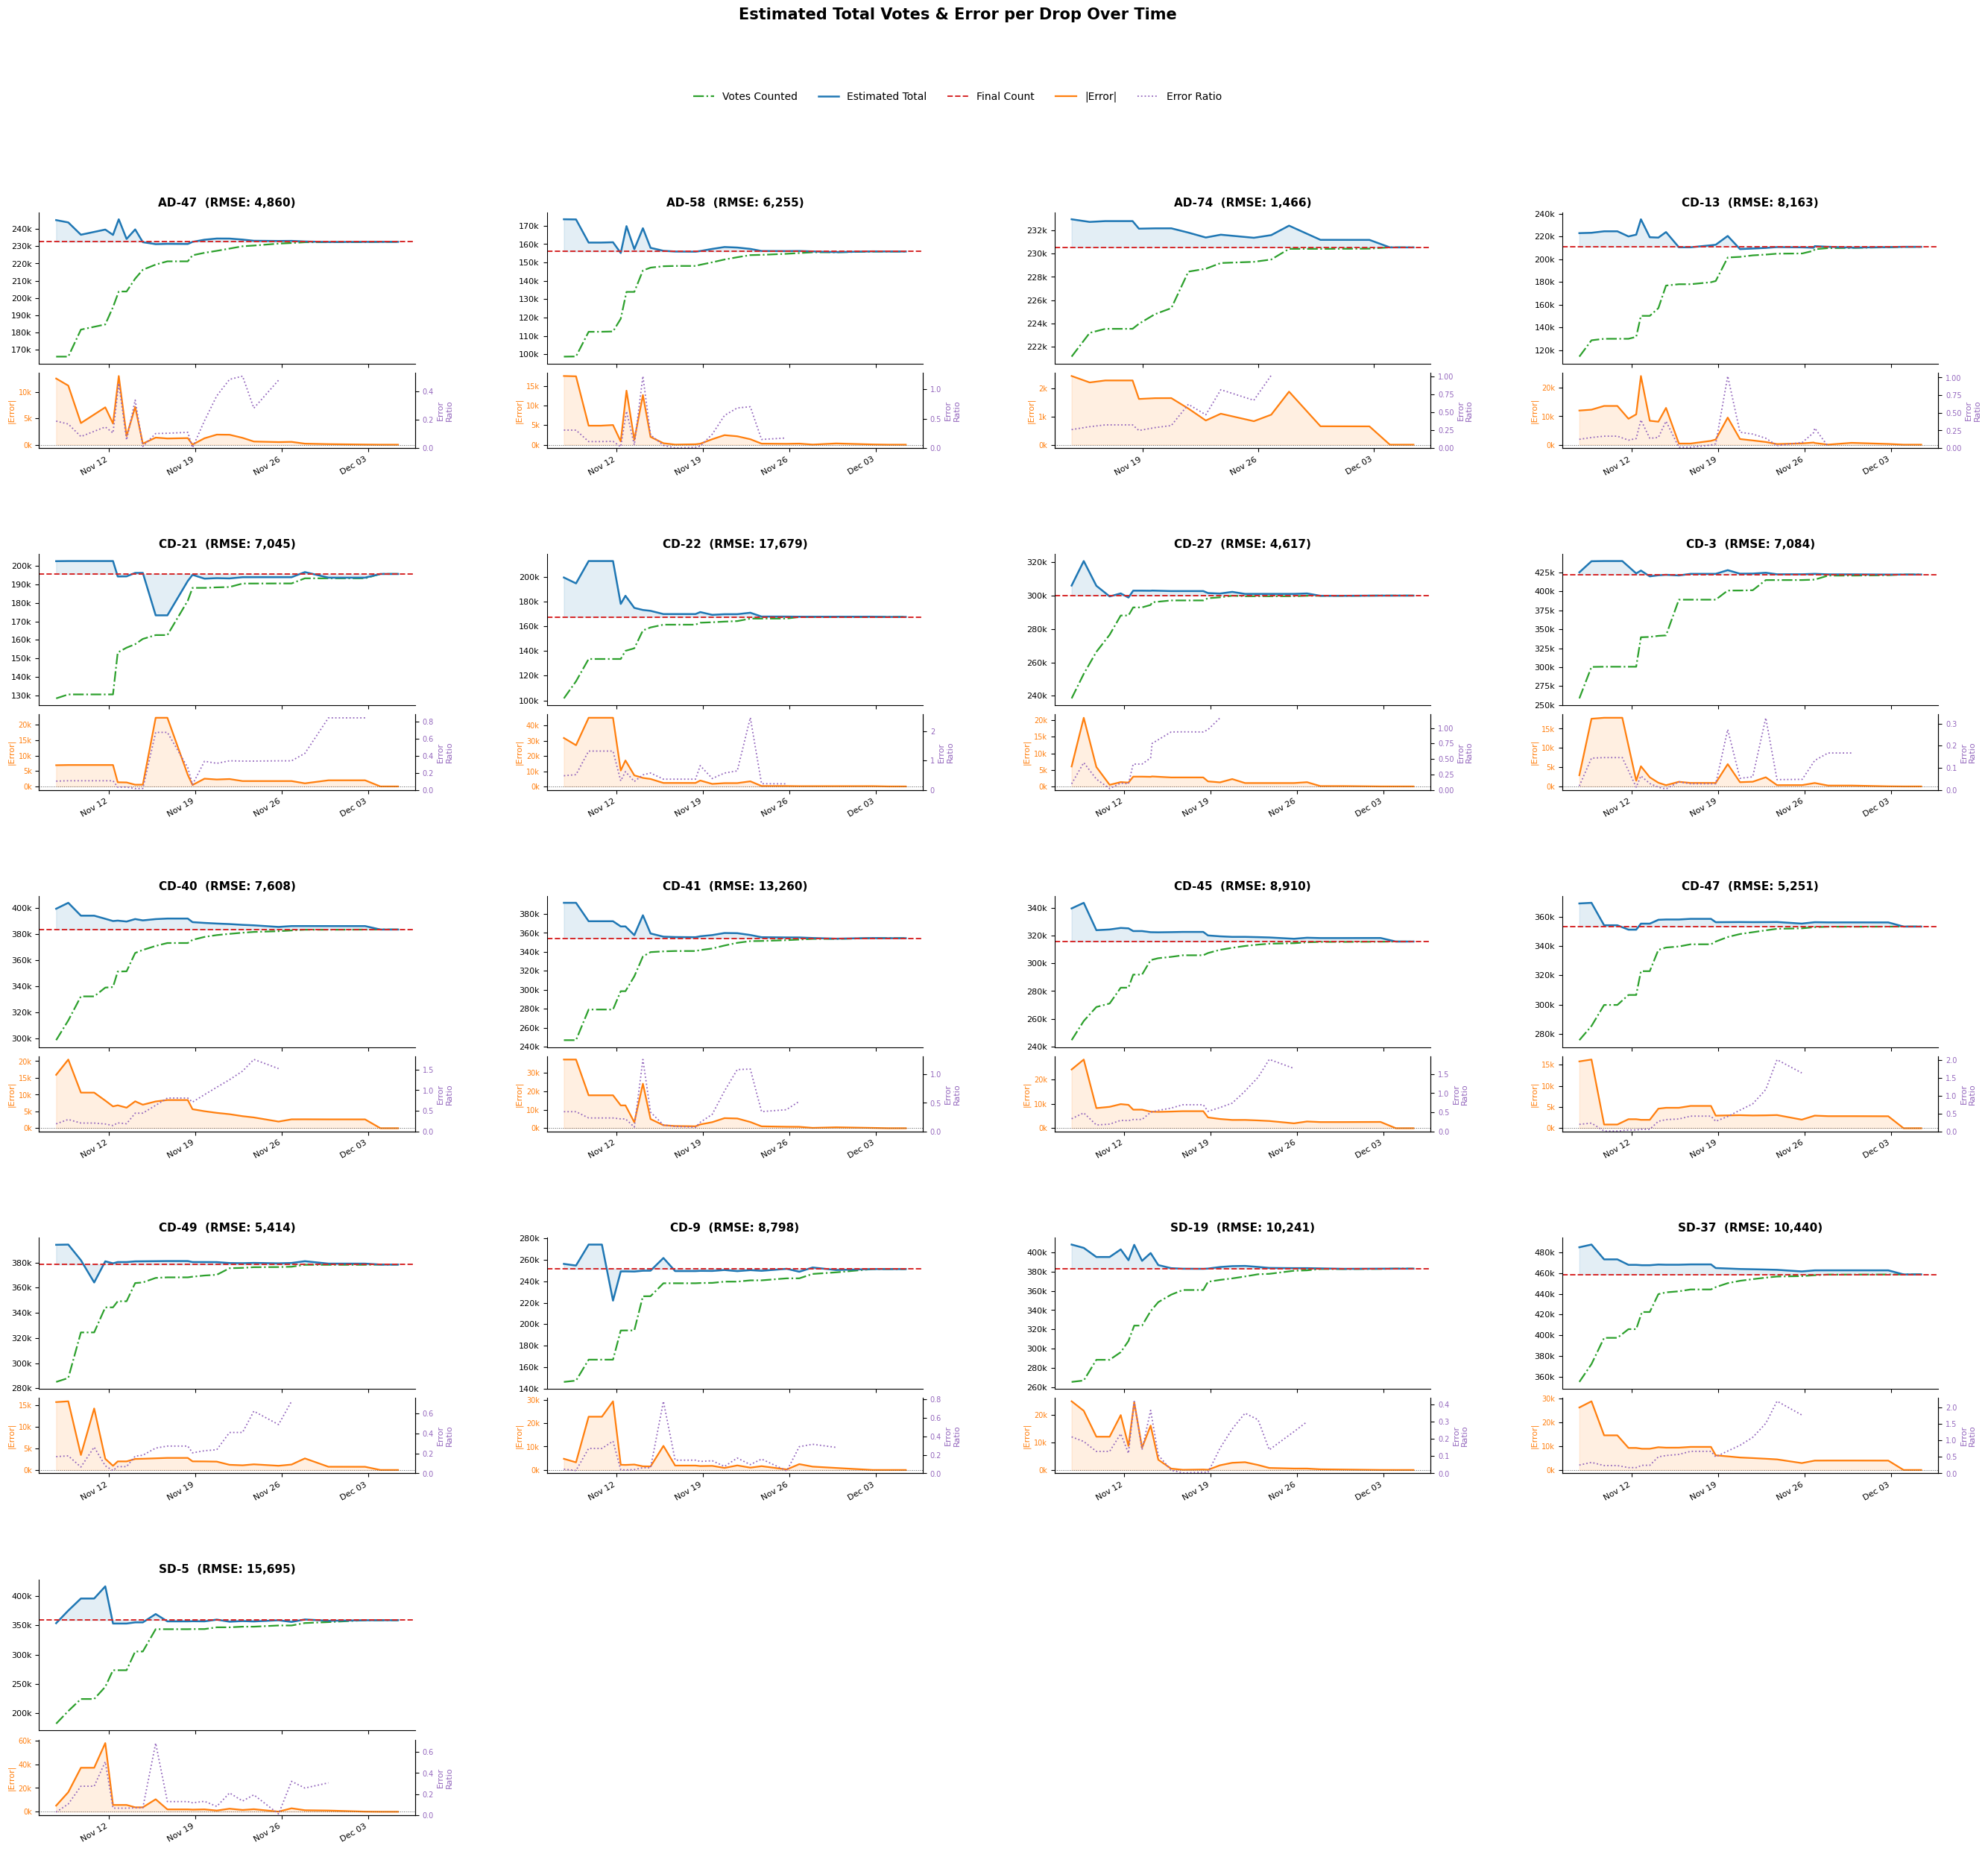

In [167]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import pandas as pd
import numpy as np

plot_df = comparison.copy()
plot_df["Datetime"] = pd.to_datetime(plot_df["Date"] + " " + plot_df["Timestamp"])

races  = sorted(plot_df["Race"].unique())
ncols  = 4
nrows  = int(np.ceil(len(races) / ncols))

fig = plt.figure(figsize=(7 * ncols, 5 * nrows), facecolor="white")
outer = gridspec.GridSpec(nrows, ncols, figure=fig,
                          hspace=0.45, wspace=0.35,
                          top=0.92, bottom=0.06, left=0.06, right=0.97)

for i, race in enumerate(races):
    row, col = divmod(i, ncols)
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[row, col], hspace=0.08, height_ratios=[2, 1]
    )
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)
    ax_rat = ax_bot.twinx()

    sub   = plot_df[plot_df["Race"] == race].sort_values("Datetime")
    final = sub["Final Total Votes Cast"].iloc[0]
    rmse  = sub["RMSE"].iloc[0]

    # --- Top: votes counted, estimated vs final ---
    ax_top.plot(sub["Datetime"], sub["Total Votes Cast"],
                color="#2ca02c", linewidth=1.6, linestyle="-.")
    ax_top.plot(sub["Datetime"], sub["Estimated Total Votes"],
                color="#1f77b4", linewidth=1.8)
    ax_top.axhline(final, color="#d62728", linewidth=1.4, linestyle="--")
    ax_top.fill_between(sub["Datetime"], sub["Estimated Total Votes"], final,
                        alpha=0.12, color="#1f77b4")
    ax_top.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
    ax_top.set_title(f"{race}  (RMSE: {rmse:,.0f})", fontsize=11, fontweight="bold")
    ax_top.tick_params(axis="both", labelsize=8)
    ax_top.spines[["top", "right"]].set_visible(False)
    plt.setp(ax_top.xaxis.get_majorticklabels(), visible=False)

    # --- Bottom left: absolute error ---
    ax_bot.plot(sub["Datetime"], sub["Error"], color="#ff7f0e", linewidth=1.6)
    ax_bot.fill_between(sub["Datetime"], sub["Error"], alpha=0.12, color="#ff7f0e")
    ax_bot.axhline(0, color="#555555", linewidth=0.7, linestyle=":")
    ax_bot.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
    ax_bot.set_ylabel("|Error|", fontsize=8, labelpad=3, color="#ff7f0e")
    ax_bot.tick_params(axis="y", labelsize=7, labelcolor="#ff7f0e")
    ax_bot.tick_params(axis="x", labelsize=8)
    ax_bot.spines[["top"]].set_visible(False)
    ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax_bot.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax_bot.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

    # --- Bottom right: error ratio ---
    ax_rat.plot(sub["Datetime"], sub["Error Ratio"], color="#9467bd",
                linewidth=1.3, linestyle=":")
    ax_rat.set_ylabel("Error\nRatio", fontsize=8, labelpad=3, color="#9467bd")
    ax_rat.tick_params(axis="y", labelsize=7, labelcolor="#9467bd")
    ax_rat.spines[["top"]].set_visible(False)
    ax_rat.set_ylim(bottom=0)

# Single legend at the top
legend_handles = [
    mlines.Line2D([], [], color="#2ca02c", linewidth=1.6, linestyle="-.", label="Votes Counted"),
    mlines.Line2D([], [], color="#1f77b4", linewidth=1.8,               label="Estimated Total"),
    mlines.Line2D([], [], color="#d62728", linewidth=1.4, linestyle="--", label="Final Count"),
    mlines.Line2D([], [], color="#ff7f0e", linewidth=1.6,               label="|Error|"),
    mlines.Line2D([], [], color="#9467bd", linewidth=1.3, linestyle=":", label="Error Ratio"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=5,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0.99))

fig.suptitle("Estimated Total Votes & Error per Drop Over Time",
             fontsize=15, fontweight="bold", y=1.03)
plt.show()


In [168]:
out_path = rf"{BASE}\2024_output\combined_races.csv"

new_cols = (
    df[["Date", "Timestamp", "Race", "Jurisdiction",
        "Estimated Votes Remaining", "Estimated Total Votes"]]
    .rename(columns={"Estimated Total Votes": "Estimated Final Vote Count"})
    .drop_duplicates(subset=["Date", "Timestamp", "Race", "Jurisdiction"])
)

# Drop existing estimated columns to avoid _x/_y suffixes on re-run
base = df_races.drop(
    columns=["Estimated Votes Remaining", "Estimated Final Vote Count"],
    errors="ignore"
)

combined = base.merge(
    new_cols,
    on=["Date", "Timestamp", "Race", "Jurisdiction"],
    how="left"
)

combined.to_csv(out_path, index=False)
print(f"Saved {len(combined)} rows to {out_path}")
combined[["Date", "Timestamp", "Race", "Jurisdiction",
          "Estimated Votes Remaining", "Estimated Final Vote Count"]].head(10)


Saved 1291 rows to C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\2024_output\combined_races.csv


,Date,Timestamp,Race,Jurisdiction,Estimated Votes Remaining,Estimated Final Vote Count
0,2024-11-05,23:46:00,CD-3,Alpine,<NA>,<NA>
1,2024-11-06,08:10:00,CD-3,Alpine,<NA>,<NA>
2,2024-11-06,17:25:00,CD-3,Alpine,<NA>,<NA>
3,2024-11-07,17:37:00,CD-3,Alpine,166486,425212
4,2024-11-08,17:12:00,CD-3,Alpine,139597,439892
5,2024-11-09,17:44:00,CD-3,Alpine,139597,440146
6,2024-11-10,19:32:00,CD-3,Alpine,139597,440146
7,2024-11-11,05:07:00,CD-3,Alpine,139597,440146
8,2024-11-12,08:08:00,CD-3,Alpine,123258,423807
9,2024-11-12,17:19:00,CD-3,Alpine,88062,427557
